# Lab 4 — Scatter Plots, Line Plots, Heatmaps
Data Visualization Lab


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

url = 'https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/athlete_events.csv'
df = pd.read_csv(url)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 1. Scatter Plot — Height vs Weight

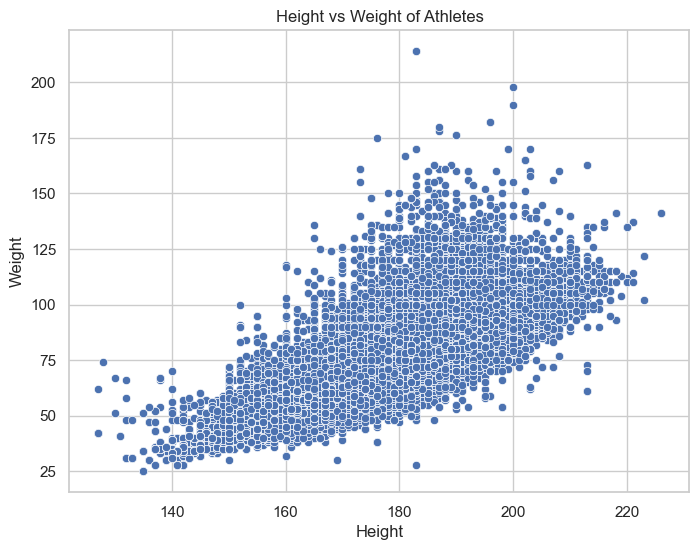

In [2]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Height', y='Weight')
plt.title('Height vs Weight of Athletes')
plt.show()

## 2. Scatter Plot with color by Sex

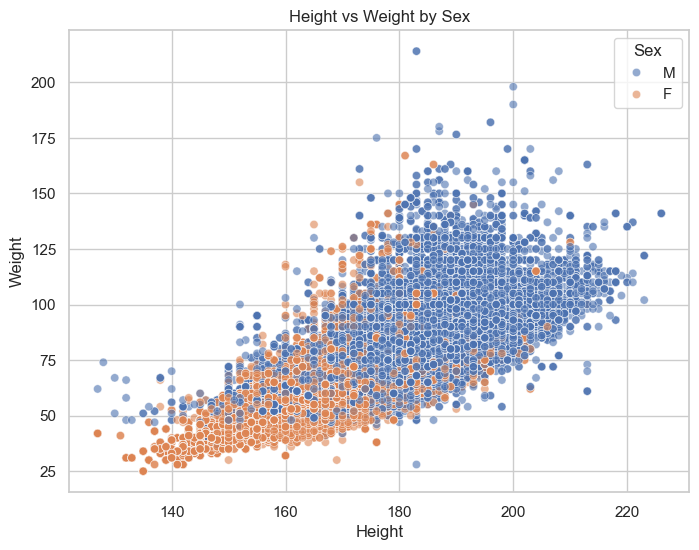

In [3]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Sex', alpha=0.6)
plt.title('Height vs Weight by Sex')
plt.show()

## 3. Line Plot — Number of athletes over time

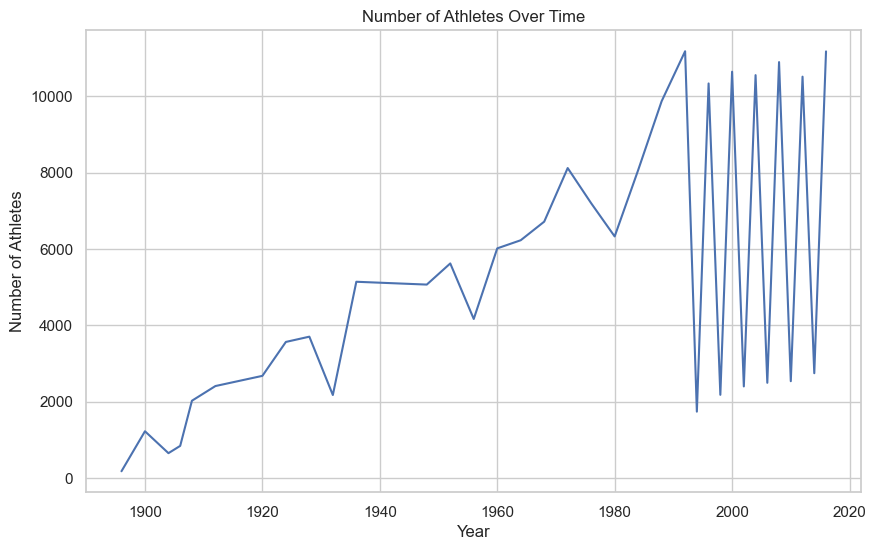

In [4]:
athletes_per_year = df.groupby('Year')['ID'].nunique()
plt.figure(figsize=(10,6))
athletes_per_year.plot()
plt.title('Number of Athletes Over Time')
plt.ylabel('Number of Athletes')
plt.show()

## 4. Line Plot by Sex

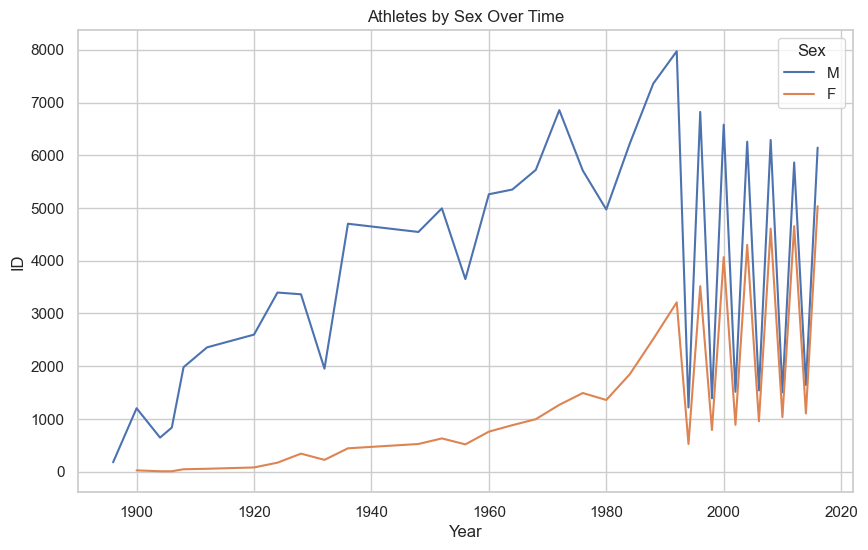

In [5]:
athletes_sex = df.groupby(['Year','Sex'])['ID'].nunique().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=athletes_sex, x='Year', y='ID', hue='Sex')
plt.title('Athletes by Sex Over Time')
plt.show()

## 5. Heatmap — Correlation

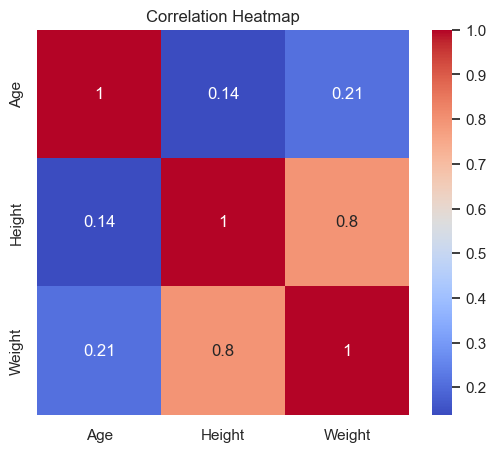

In [6]:
corr = df[['Age','Height','Weight']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 6. Heatmap — Medals by Sport and Sex

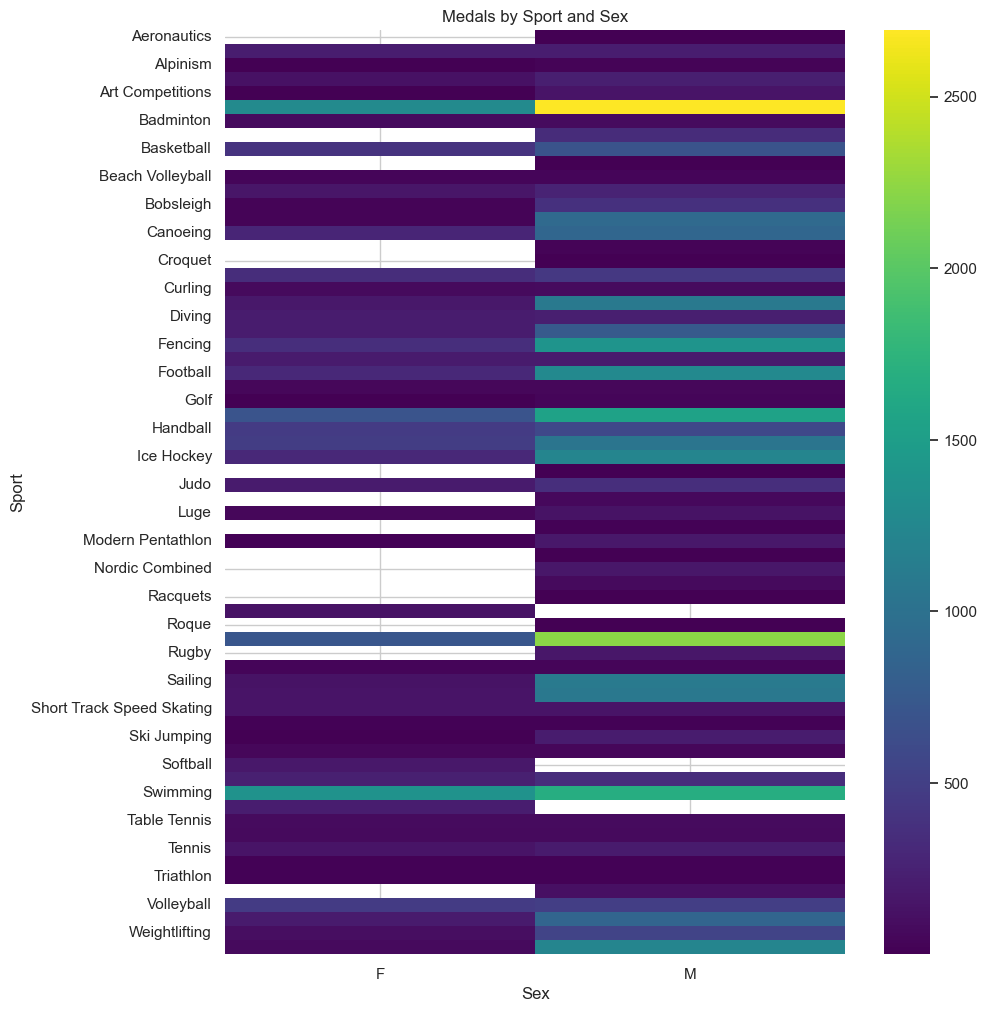

In [7]:
medals = df[df['Medal'].notna()]
pivot = medals.pivot_table(index='Sport', columns='Sex', values='ID', aggfunc='count')
plt.figure(figsize=(10,12))
sns.heatmap(pivot, cmap='viridis')
plt.title('Medals by Sport and Sex')
plt.show()